In [4]:
import argparse
import array
import base64
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import sys
# from tcam import TCam
import json

In [8]:
# Read the file
with open('./raw_files/tcam_2024-11-25 03-06-17.tjsn', 'r') as file:
    img_json = json.load(file)  # Parse JSON content

Max val is 30534, Min val is 28421, Delta is 2113


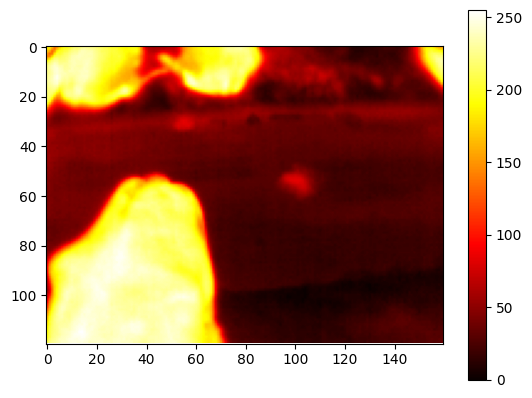

In [13]:
dec_rad = base64.b64decode(img_json["radiometric"])
ra = array.array('H', dec_rad)

#
# Determine minimum/maximum 16-bit values in radiometric data
#
imgmin = 65535
imgmax = 0

for i in ra:
    if i < imgmin:
        imgmin = i
    if i > imgmax:
        imgmax = i

delta = imgmax - imgmin
print(f"Max val is {imgmax}, Min val is {imgmin}, Delta is {delta}")

#
# Linearize 16-bit data within range imgmin/imgmax to an 8-bit image
#
a = np.zeros((120, 160, 3), np.uint8)
for r in range(0, 120):
    for c in range(0, 160):
        val = int((ra[(r * 160) + c] - imgmin) * 255 / delta)
        if val > 255:
            a[r, c] = [255, 255, 255]
        else:
            a[r, c] = [val, val, val]

#
# Slice into a single-color image so we can colorize it using a palette
#
lum_img = a[:, :, 0]

#
# Display
#  Note: supported interpolation values are 'antialiased', 'none', 'nearest', 'bilinear',
#   'bicubic', 'spline16', 'spline36', 'hanning', 'hamming', 'hermite', 'kaiser',
#   'quadric', 'catrom', 'gaussian', 'bessel', 'mitchell', 'sinc', 'lanczos', 'blackman'
#
plt.imshow(lum_img, interpolation="antialiased", cmap='hot')
plt.colorbar()
plt.show()